
# ¿Qué hace realmente una convolución?

En este notebook **no vamos a clasificar imágenes**.

No habrá:

- `Softmax`
- `CrossEntropyLoss`
- accuracy
- clases

El objetivo es aislar una sola idea:

> **Una capa convolucional aplica pequeños filtros locales sobre una imagen y produce feature maps.**

Vamos a construir el concepto paso a paso:

```text
imagen
  ↓
parche local
  ↓
kernel
  ↓
producto elemento a elemento
  ↓
suma
  ↓
una activación
  ↓
repetimos en toda la imagen
  ↓
feature map
```

Después veremos que los valores del kernel pueden ser **parámetros aprendibles**.

---

## Objetivos

Al terminar deberías poder explicar:

1. Qué es un **kernel** o filtro.
2. Qué calcula una convolución en una posición.
3. Qué es un **feature map**.
4. Por qué un mismo kernel puede detectar un patrón en distintas posiciones.
5. Cuántos parámetros tiene una capa `Conv2d`.
6. Qué significa `in_channels` y `out_channels`.
7. Cómo se relaciona una implementación manual con `nn.Conv2d`.
8. Cómo un kernel puede aprenderse mediante gradiente descendente sin hacer clasificación.

> Nota: en deep learning, `Conv2d` de PyTorch implementa técnicamente **cross-correlation**: el kernel no se invierte antes de aplicarlo. En la práctica se suele hablar simplemente de "convolución".


In [1]:

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)


PyTorch: 2.11.0+cpu



# 1. Empecemos con una imagen extremadamente simple

Usaremos una imagen en escala de grises de `12 × 12`.

Los valores serán:

- `0`: píxel oscuro.
- `1`: píxel claro.

En el centro dibujaremos un cuadrado blanco.

Esto permite ver claramente dónde aparecen los bordes.


Shape: torch.Size([12, 12])


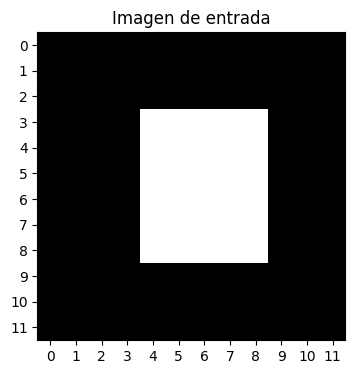

In [2]:

image = torch.zeros(12, 12)

# Cuadrado blanco
image[3:9, 4:9] = 1.0

print("Shape:", image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray", vmin=0, vmax=1)
plt.title("Imagen de entrada")
plt.xticks(range(12))
plt.yticks(range(12))
plt.grid(False)
plt.show()



# 2. Un kernel

Un kernel es una pequeña matriz de números.

Por ejemplo:

$$
K =
\begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{bmatrix}
$$

Este kernel responde a **cambios horizontales de intensidad**, por lo que puede detectar bordes verticales.

La intuición:

```text
oscuro | claro
   0   |   1
```

produce una respuesta grande porque el kernel compara lo que ocurre a la izquierda con lo que ocurre a la derecha.

El kernel tiene tamaño:

$$
3 \times 3
$$

y por ahora sus valores son escogidos manualmente.


In [3]:

kernel_vertical = torch.tensor([
    [-1., 0., 1.],
    [-1., 0., 1.],
    [-1., 0., 1.],
])

kernel_vertical


tensor([[-1.,  0.,  1.],
        [-1.,  0.,  1.],
        [-1.,  0.,  1.]])


# 3. ¿Qué calcula la convolución en una posición?

Tomamos un parche de la imagen del mismo tamaño que el kernel:

$$
3\times3
$$

Luego hacemos:

$$
\text{salida}
=
\sum
\left(
\text{parche}
\odot
\text{kernel}
\right)
$$

donde \(\odot\) representa multiplicación elemento a elemento.

Veamos una sola posición.


In [4]:

row = 3
col = 3

patch = image[row:row+3, col:col+3]

products = patch * kernel_vertical
activation = products.sum()

print("PATCH")
print(patch)

print("\nKERNEL")
print(kernel_vertical)

print("\nPRODUCTO ELEMENTO A ELEMENTO")
print(products)

print("\nSUMA =", activation.item())


PATCH
tensor([[0., 1., 1.],
        [0., 1., 1.],
        [0., 1., 1.]])

KERNEL
tensor([[-1.,  0.,  1.],
        [-1.,  0.,  1.],
        [-1.,  0.,  1.]])

PRODUCTO ELEMENTO A ELEMENTO
tensor([[-0., 0., 1.],
        [-0., 0., 1.],
        [-0., 0., 1.]])

SUMA = 3.0



Ese único número es la respuesta del filtro en **una posición de la imagen**.

El kernel no produce directamente una clase.

Produce una medida de:

> **¿Cuánto se parece este parche local al patrón al que responde el kernel?**

Ahora debemos repetir exactamente la misma operación desplazando el kernel por toda la imagen.



# 4. Hagamos la operación completa desde cero

Para simplificar:

- kernel: `3 × 3`
- stride: `1`
- padding: `0`

Si la imagen es:

$$
12\times12
$$

la salida tendrá:

$$
(12-3)+1 = 10
$$

por tanto:

$$
10\times10
$$

Cada posición del feature map corresponde a una región local diferente de la imagen.


In [5]:

def conv2d_manual(image, kernel):
    H, W = image.shape
    kH, kW = kernel.shape

    out_H = H - kH + 1
    out_W = W - kW + 1

    feature_map = torch.zeros(out_H, out_W)

    for i in range(out_H):
        for j in range(out_W):
            patch = image[i:i+kH, j:j+kW]

            feature_map[i, j] = torch.sum(
                patch * kernel
            )

    return feature_map


feature_vertical = conv2d_manual(
    image,
    kernel_vertical
)

print("Input shape:", image.shape)
print("Kernel shape:", kernel_vertical.shape)
print("Feature map shape:", feature_vertical.shape)


Input shape: torch.Size([12, 12])
Kernel shape: torch.Size([3, 3])
Feature map shape: torch.Size([10, 10])


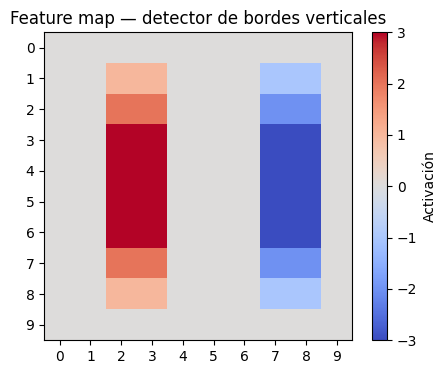

In [6]:

plt.figure(figsize=(5, 4))
plt.imshow(feature_vertical, cmap="coolwarm")
plt.title("Feature map — detector de bordes verticales")
plt.colorbar(label="Activación")
plt.xticks(range(feature_vertical.shape[1]))
plt.yticks(range(feature_vertical.shape[0]))
plt.grid(False)
plt.show()



# 5. ¿Qué es entonces un feature map?

Un **feature map** es la respuesta de un filtro en todas las posiciones espaciales.

```text
                 mismo kernel
                      ↓
imagen ──────────────────────────────
        ↓       ↓       ↓       ↓
      patch   patch   patch   patch
        ↓       ↓       ↓       ↓
      valor   valor   valor   valor
        └───────┬───────┬───────┘
                ↓
            FEATURE MAP
```

Cada celda responde:

> **¿Cuánto se activó este filtro en esta región de la imagen?**

En este ejemplo el filtro busca principalmente **bordes verticales**.

Por eso las activaciones fuertes deberían aparecer cerca de los lados verticales del cuadrado.

---

## Importante

Un feature map todavía conserva información espacial.

Si una activación grande aparece arriba a la izquierda del feature map, sabemos que el patrón fue encontrado aproximadamente arriba a la izquierda de la imagen.



# 6. ¿Qué significan los valores positivos y negativos?

Con nuestro kernel:

$$
[-1,\ 0,\ 1]
$$

un cambio:

```text
oscuro → claro
```

produce un signo, mientras que:

```text
claro → oscuro
```

produce el signo contrario.

Por eso aparecen valores positivos y negativos.

Veamos qué ocurre si aplicamos `ReLU`.


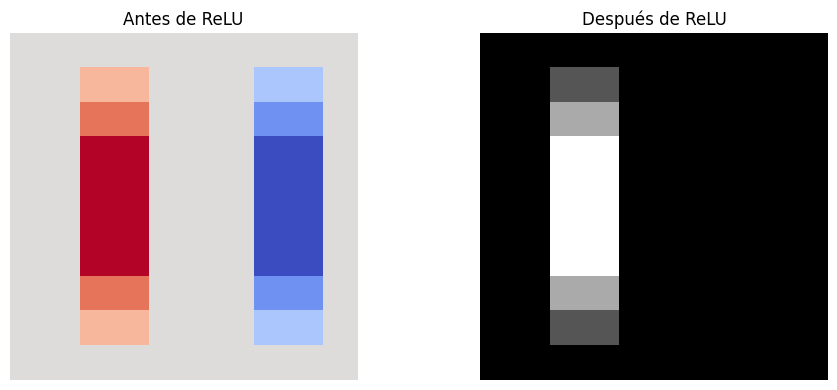

In [7]:

feature_vertical_relu = torch.relu(feature_vertical)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(feature_vertical, cmap="coolwarm")
axes[0].set_title("Antes de ReLU")
axes[0].axis("off")

axes[1].imshow(feature_vertical_relu, cmap="gray")
axes[1].set_title("Después de ReLU")
axes[1].axis("off")

plt.tight_layout()
plt.show()



Conviene distinguir:

```text
Conv2d
  ↓
feature map
  ↓
ReLU
  ↓
activation map
```

En muchos textos ambos términos se usan de forma menos estricta y se llama `feature map` también al resultado después de la activación.

Lo importante conceptualmente es saber **en qué punto de la red estamos**.



# 7. Un filtro diferente extrae una característica diferente

Ahora usemos:

$$
K =
\begin{bmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
1 & 1 & 1
\end{bmatrix}
$$

Este filtro responde principalmente a **bordes horizontales**.


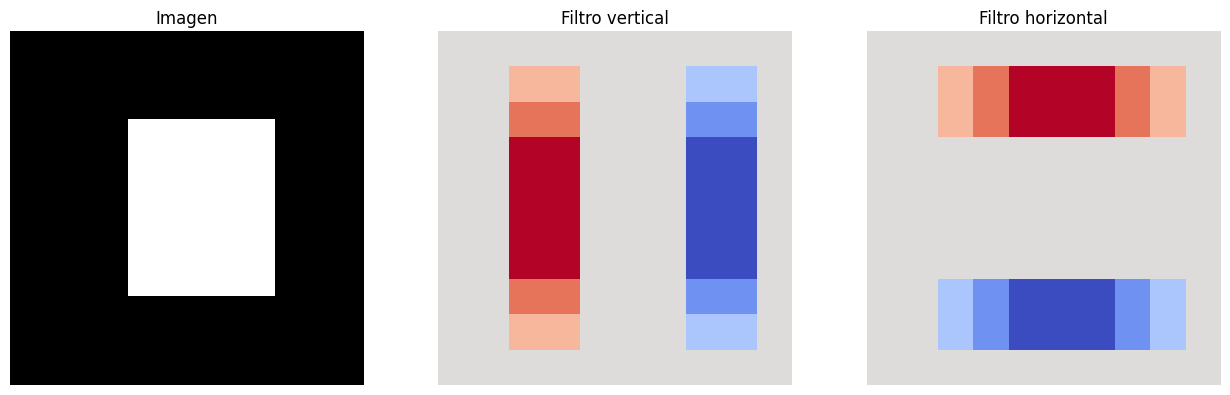

In [8]:

kernel_horizontal = torch.tensor([
    [-1., -1., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  1.,  1.],
])

feature_horizontal = conv2d_manual(
    image,
    kernel_horizontal
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Imagen")
axes[0].axis("off")

axes[1].imshow(feature_vertical, cmap="coolwarm")
axes[1].set_title("Filtro vertical")
axes[1].axis("off")

axes[2].imshow(feature_horizontal, cmap="coolwarm")
axes[2].set_title("Filtro horizontal")
axes[2].axis("off")

plt.tight_layout()
plt.show()



## Idea fundamental

```text
un kernel
   ↓
un feature map

varios kernels
   ↓
varios feature maps
```

Una capa convolucional no tiene necesariamente un solo filtro.

Por ejemplo:

```python
nn.Conv2d(
    in_channels=1,
    out_channels=4,
    kernel_size=3
)
```

contiene **4 filtros aprendibles**.

Cada filtro produce su propio feature map.

Por tanto la salida tiene forma:

$$
[B, 4, H_{out}, W_{out}]
$$



# 8. Veamos varios filtros al mismo tiempo

Vamos a definir manualmente cuatro filtros:

1. borde vertical;
2. borde horizontal;
3. promedio local;
4. detector simple de contraste central.

No son "los filtros correctos" de una CNN.

Solo sirven para visualizar que **distintos kernels producen distintas representaciones de la misma imagen**.


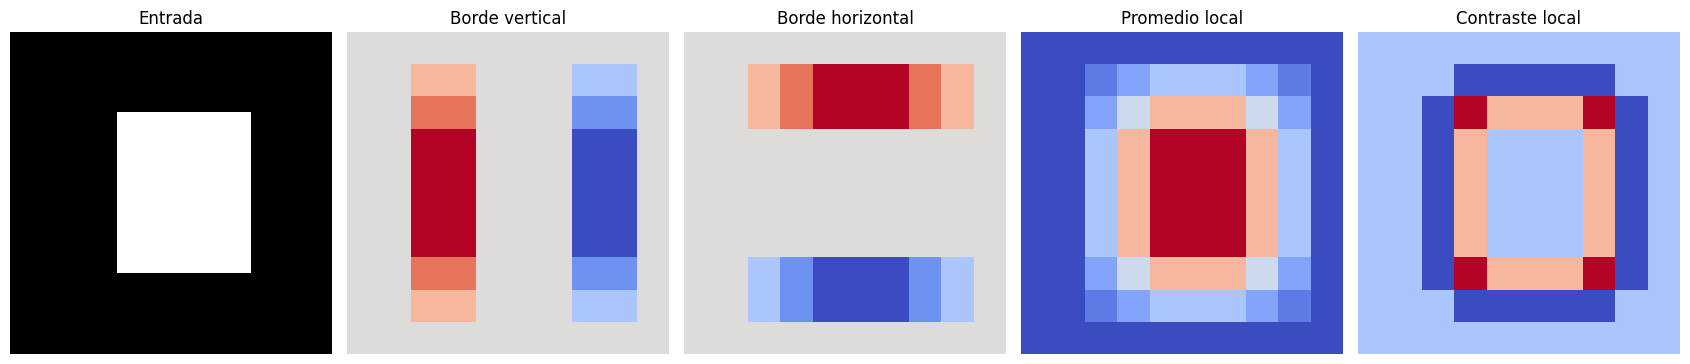

In [9]:

kernel_blur = torch.ones(3, 3) / 9.0

kernel_center = torch.tensor([
    [ 0., -1.,  0.],
    [-1.,  4., -1.],
    [ 0., -1.,  0.],
])

kernels = {
    "Borde vertical": kernel_vertical,
    "Borde horizontal": kernel_horizontal,
    "Promedio local": kernel_blur,
    "Contraste local": kernel_center,
}

features = {
    name: conv2d_manual(image, kernel)
    for name, kernel in kernels.items()
}

fig, axes = plt.subplots(1, 5, figsize=(17, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Entrada")
axes[0].axis("off")

for ax, (name, fmap) in zip(axes[1:], features.items()):
    ax.imshow(fmap, cmap="coolwarm")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()



# 9. ¿Dónde están los parámetros?

Hasta ahora escogimos manualmente los números del kernel.

Pero en una CNN real:

```text
-0.12   0.08   0.31
 0.44  -0.20   0.05
 0.17   0.09  -0.35
```

son **parámetros aprendibles**.

Para una imagen de un solo canal y un filtro `3 × 3`:

$$
3\times3=9
$$

pesos.

Si además usamos bias:

$$
9 + 1 = 10
$$

parámetros.

---

Una regla general para `Conv2d` es:

$$
\text{parámetros}
=
C_{out}
\left(
C_{in}K_HK_W + 1
\right)
$$

si hay bias.

Observa algo importante:

> **El número de parámetros no depende de la altura ni del ancho de la imagen.**

El mismo kernel se reutiliza en toda la imagen.

Eso es **weight sharing**.


In [10]:

def conv_parameter_count(
    in_channels,
    out_channels,
    kernel_size,
    bias=True
):
    kH, kW = kernel_size

    weights = (
        out_channels
        * in_channels
        * kH
        * kW
    )

    biases = out_channels if bias else 0

    return weights + biases


examples = [
    (1, 1, (3, 3)),
    (1, 4, (3, 3)),
    (3, 8, (3, 3)),
]

for c_in, c_out, k in examples:
    params = conv_parameter_count(
        c_in,
        c_out,
        k,
        bias=True
    )

    print(
        f"in={c_in}, out={c_out}, kernel={k}: "
        f"{params} parámetros"
    )


in=1, out=1, kernel=(3, 3): 10 parámetros
in=1, out=4, kernel=(3, 3): 40 parámetros
in=3, out=8, kernel=(3, 3): 224 parámetros



# 10. La misma operación con PyTorch

Ahora construiremos una sola capa:

```python
nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    bias=False
)
```

y copiaremos manualmente nuestro kernel dentro de sus pesos.

Así podremos comprobar que nuestra implementación manual y PyTorch producen el mismo resultado.


In [11]:

conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    bias=False,
)

with torch.no_grad():
    conv.weight[0, 0] = kernel_vertical

# Conv2d espera:
# [batch, channels, height, width]
x = image.unsqueeze(0).unsqueeze(0)

feature_pytorch = conv(x)

print("Input:", x.shape)
print("Pesos:", conv.weight.shape)
print("Output:", feature_pytorch.shape)

difference = (
    feature_pytorch[0, 0]
    - feature_vertical
).abs().max()

print("Máxima diferencia:", difference.item())


Input: torch.Size([1, 1, 12, 12])
Pesos: torch.Size([1, 1, 3, 3])
Output: torch.Size([1, 1, 10, 10])
Máxima diferencia: 0.0



Observa los shapes:

```text
Input:
[B, C_in, H, W]

Weights:
[C_out, C_in, K_H, K_W]

Output:
[B, C_out, H_out, W_out]
```

Para nuestro ejemplo:

```text
Input   = [1, 1, 12, 12]
Weights = [1, 1,  3,  3]
Output  = [1, 1, 10, 10]
```

El `1` de `C_out` significa:

> Tenemos un filtro y por tanto obtenemos un feature map por imagen.



# 11. Dos filtros = dos feature maps

Ahora construiremos:

```python
nn.Conv2d(
    in_channels=1,
    out_channels=2,
    kernel_size=3,
    bias=False
)
```

y pondremos:

- filtro vertical;
- filtro horizontal.

La imagen será la misma.

Lo que cambia es **qué característica busca cada filtro**.


In [12]:

conv2 = nn.Conv2d(
    in_channels=1,
    out_channels=2,
    kernel_size=3,
    bias=False,
)

with torch.no_grad():
    conv2.weight[0, 0] = kernel_vertical
    conv2.weight[1, 0] = kernel_horizontal

features_2 = conv2(x)

print("Weights:", conv2.weight.shape)
print("Output:", features_2.shape)


Weights: torch.Size([2, 1, 3, 3])
Output: torch.Size([1, 2, 10, 10])


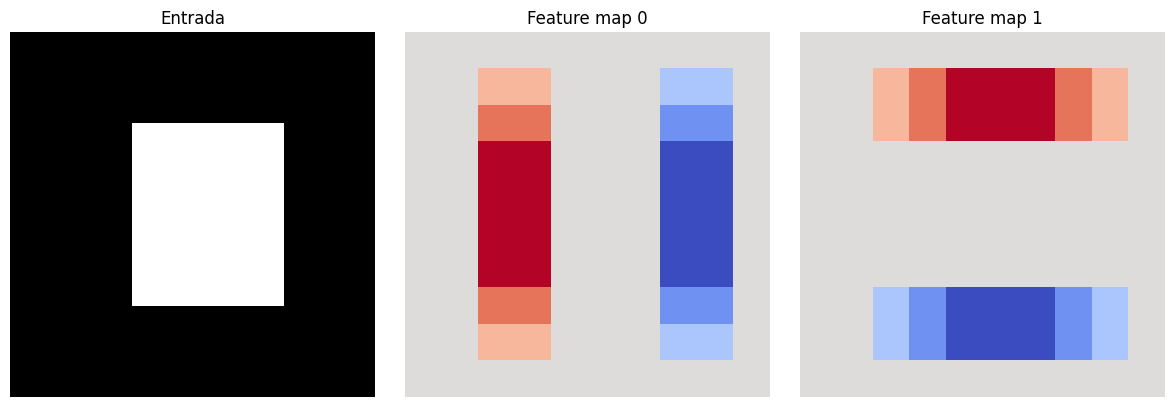

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Entrada")
axes[0].axis("off")

axes[1].imshow(features_2[0, 0].detach(), cmap="coolwarm")
axes[1].set_title("Feature map 0")
axes[1].axis("off")

axes[2].imshow(features_2[0, 1].detach(), cmap="coolwarm")
axes[2].set_title("Feature map 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()



# 12. Entonces, ¿qué "extrae" una convolución?

No debemos pensar que una convolución siempre extrae "bordes".

Lo correcto es:

> Cada kernel produce una respuesta alta para ciertos patrones locales determinados por sus pesos.

Si los pesos son diseñados manualmente, sabemos qué patrón buscamos.

Si los pesos son aprendidos:

```text
inicialización aleatoria
        ↓
      loss
        ↓
   gradientes
        ↓
actualización del kernel
        ↓
el kernel aprende un patrón útil
```

Ahora vamos a hacer exactamente eso.

Pero **sin clasificación**.



# 13. Aprender una convolución sin clasificación

Construiremos un problema artificial.

Queremos que una capa convolucional aprenda a producir un feature map que marque **bordes verticales**.

Tendremos:

```text
imagen sintética
      │
      ├──────────────→ filtro objetivo
      │                       ↓
      │                feature map objetivo
      │
      ↓
Conv2d aprendible
      ↓
feature map predicho
      │
      ▼
MSE(predicho, objetivo)
```

La loss será:

$$
\mathcal{L}
=
\frac{1}{N}
\sum_i
\left(
\hat{F}_i-F_i
\right)^2
$$

No estamos preguntando:

> ¿qué clase es esta imagen?

Estamos preguntando:

> ¿puede esta convolución aprender a producir el feature map que queremos?



## 13.1 Dataset sintético

Generaremos pequeñas imágenes con rectángulos colocados en posiciones aleatorias.

El feature map objetivo será creado con nuestro filtro vertical conocido.

Esto nos permite conocer cuál es la operación que queremos que la capa aprenda.


In [14]:

def make_random_rectangle_image(size=16):
    img = torch.zeros(size, size)

    width = random.randint(2, 6)
    height = random.randint(3, 10)

    row = random.randint(1, size - height - 1)
    col = random.randint(1, size - width - 1)

    img[row:row+height, col:col+width] = 1.0

    return img


N = 128

X_train = torch.stack([
    make_random_rectangle_image()
    for _ in range(N)
])

# [N, H, W] -> [N, 1, H, W]
X_train = X_train.unsqueeze(1)

teacher_kernel = kernel_vertical.view(1, 1, 3, 3)

with torch.no_grad():
    Y_target = F.conv2d(
        X_train,
        teacher_kernel,
        bias=None,
    )

print("Inputs:", X_train.shape)
print("Targets:", Y_target.shape)


Inputs: torch.Size([128, 1, 16, 16])
Targets: torch.Size([128, 1, 14, 14])


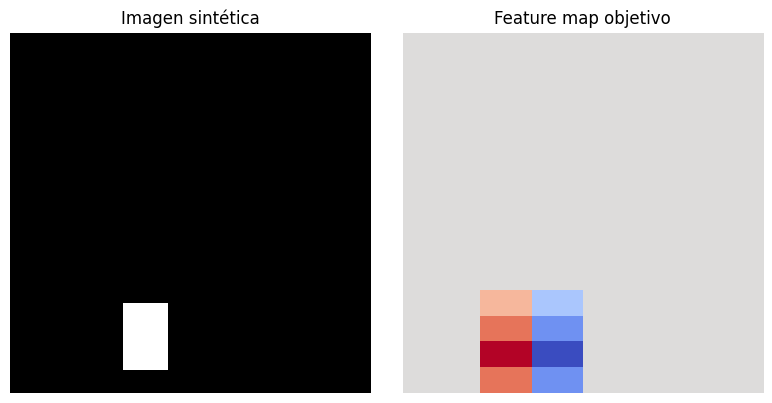

In [15]:

sample = 0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(X_train[sample, 0], cmap="gray")
axes[0].set_title("Imagen sintética")
axes[0].axis("off")

axes[1].imshow(Y_target[sample, 0], cmap="coolwarm")
axes[1].set_title("Feature map objetivo")
axes[1].axis("off")

plt.tight_layout()
plt.show()



# 14. Una capa con 9 parámetros aprendibles

Crearemos:

```python
nn.Conv2d(
    1,
    1,
    kernel_size=3,
    bias=False
)
```

Tiene exactamente:

$$
1\times1\times3\times3=9
$$

parámetros.

Inicialmente esos valores son aleatorios.

El objetivo del entrenamiento será modificar esos **9 números**.


In [16]:

student_conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    bias=False,
)

print("Kernel inicial:")
print(student_conv.weight.detach()[0, 0])

print("\nNúmero de parámetros:")
print(sum(p.numel() for p in student_conv.parameters()))


Kernel inicial:
tensor([[-0.2004,  0.0315, -0.3292],
        [ 0.3010, -0.2832,  0.2573],
        [ 0.0555, -0.1082,  0.2060]])

Número de parámetros:
9



# 15. Loss sobre feature maps

La salida de nuestra convolución tiene forma:

```text
[N, 1, 14, 14]
```

y el target también.

Por tanto podemos medir directamente:

```python
MSE(
    feature_map_predicho,
    feature_map_objetivo
)
```

No necesitamos una capa final de clasificación.


In [17]:

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    student_conv.parameters(),
    lr=0.05,
)

loss_history = []

for epoch in range(101):

    predicted_map = student_conv(X_train)

    loss = criterion(
        predicted_map,
        Y_target
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.6f}"
        )


Epoch 000 | Loss: 0.973202
Epoch 020 | Loss: 0.017537
Epoch 040 | Loss: 0.015324
Epoch 060 | Loss: 0.002183
Epoch 080 | Loss: 0.001131
Epoch 100 | Loss: 0.000744


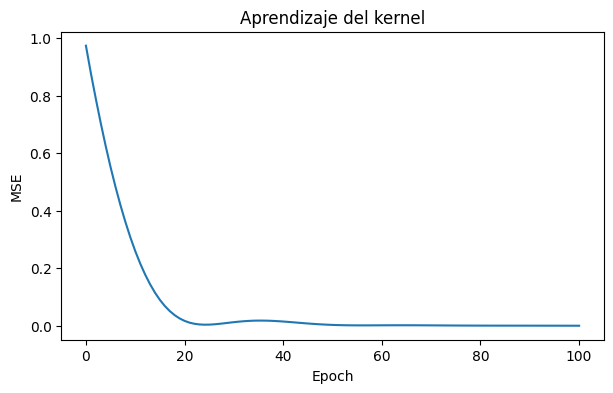

In [18]:

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Aprendizaje del kernel")
plt.grid(False)
plt.show()



# 16. ¿Qué aprendió?

Comparemos:

```text
kernel objetivo
vs
kernel aprendido
```

Si el entrenamiento funcionó, los pesos deberían aproximarse al filtro que genera los bordes verticales.


In [19]:

learned_kernel = student_conv.weight.detach()[0, 0]

print("KERNEL OBJETIVO")
print(kernel_vertical)

print("\nKERNEL APRENDIDO")
print(learned_kernel)


KERNEL OBJETIVO
tensor([[-1.,  0.,  1.],
        [-1.,  0.,  1.],
        [-1.,  0.,  1.]])

KERNEL APRENDIDO
tensor([[-1.1662,  0.2538,  0.8312],
        [-0.8184, -0.2592,  1.1636],
        [-1.0364,  0.0219,  1.0050]])


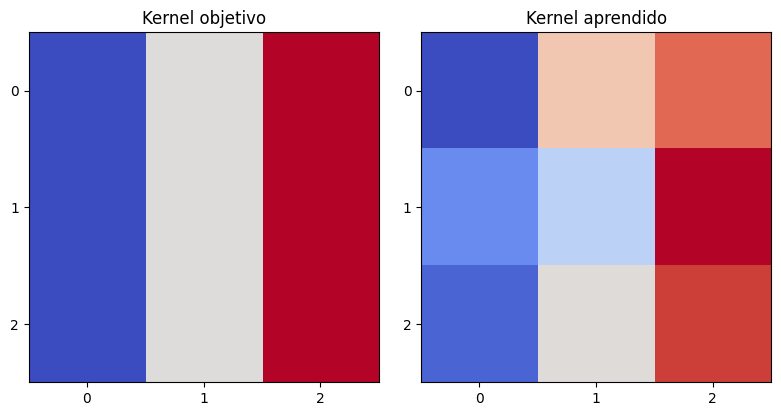

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(kernel_vertical, cmap="coolwarm")
axes[0].set_title("Kernel objetivo")

axes[1].imshow(learned_kernel, cmap="coolwarm")
axes[1].set_title("Kernel aprendido")

for ax in axes:
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))

plt.tight_layout()
plt.show()



# 17. Feature map objetivo vs aprendido

La pregunta importante no es solamente si los pesos se parecen.

Queremos comprobar si producen **la representación deseada**.


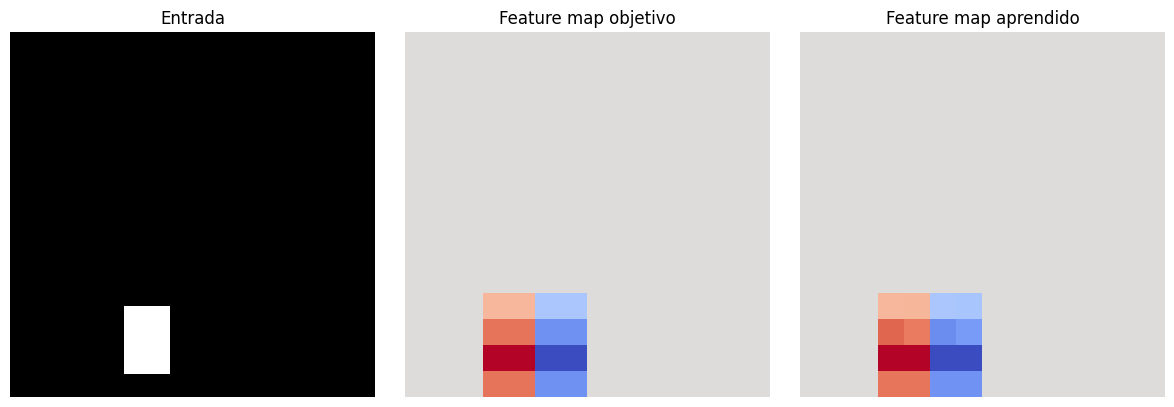

In [21]:

with torch.no_grad():
    predicted = student_conv(X_train[sample:sample+1])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(X_train[sample, 0], cmap="gray")
axes[0].set_title("Entrada")
axes[0].axis("off")

axes[1].imshow(Y_target[sample, 0], cmap="coolwarm")
axes[1].set_title("Feature map objetivo")
axes[1].axis("off")

axes[2].imshow(predicted[0, 0], cmap="coolwarm")
axes[2].set_title("Feature map aprendido")
axes[2].axis("off")

plt.tight_layout()
plt.show()



# 18. ¿Qué ocurrió durante el entrenamiento?

La red completa era solamente:

```text
            9 parámetros
                 ↓
imagen → Conv2d 3×3 → feature map
                         │
                         ▼
                        MSE
                         │
                         ▼
                    gradientes
                         │
                         ▼
               actualizar kernel
```

No había clasificador.

No había una capa `Linear`.

No había `Softmax`.

El entrenamiento modificó directamente los valores del kernel para que la convolución produjera el **feature map deseado**.

Esta es la idea esencial detrás de una CNN:

> **Los filtros no tienen que ser diseñados manualmente. Pueden aprenderse a partir de una función de costo.**



# 19. De una capa a una CNN profunda

En una primera capa:

```text
imagen
 ↓
Conv
 ↓
bordes / contrastes / patrones simples
```

En capas posteriores, el input ya no es la imagen original.

Es un conjunto de feature maps:

```text
feature maps de capa 1
          ↓
        Conv
          ↓
feature maps de capa 2
```

Por tanto los filtros posteriores pueden combinar patrones más simples para representar patrones progresivamente más complejos.

Una forma conceptual de visualizarlo es:

```text
píxeles
  ↓
bordes
  ↓
texturas / formas simples
  ↓
partes
  ↓
representaciones más abstractas
```

Esto es una **intuición**, no una regla rígida sobre lo que necesariamente aprende cada capa.



# 20. Preguntas para discutir

### Pregunta 1

¿Qué representa una sola celda de un feature map?

---

### Pregunta 2

¿Por qué un filtro `3 × 3` tiene los mismos parámetros independientemente de si la imagen mide:

```text
32 × 32
```

o:

```text
1024 × 1024
```

?

---

### Pregunta 3

¿Qué significa **weight sharing**?

---

### Pregunta 4

Si una capa tiene:

```python
nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    bias=True
)
```

¿cuántos parámetros tiene?

---

### Pregunta 5

¿Por qué `out_channels=16` significa que obtenemos 16 feature maps por imagen?

---

### Pregunta 6

¿Qué diferencia hay entre:

```text
kernel
```

y:

```text
feature map
```

?

---

### Pregunta 7

En el experimento de aprendizaje:

- ¿qué eran los parámetros?
- ¿qué era la predicción?
- ¿qué era el target?
- ¿qué medía la loss?

---

### Pregunta 8

¿Por qué este ejemplo demuestra que podemos entrenar una convolución sin tener un problema de clasificación?



# 21. Mini-retos

## Reto A — Cambia el kernel

Diseña un kernel `3 × 3` diferente y observa qué feature map produce.

---

## Reto B — Cambia la imagen

Agrega:

- dos cuadrados;
- una línea;
- una cruz;
- un rectángulo.

¿El mismo filtro sigue respondiendo al mismo tipo de patrón?

---

## Reto C — Cambia el número de filtros

Construye una capa con:

```python
out_channels=3
```

y coloca manualmente tres kernels diferentes.

Comprueba el shape de salida.

---

## Reto D — Aprende otro filtro

Cambia `teacher_kernel` por otro kernel conocido.

Por ejemplo:

```python
kernel_horizontal
```

y comprueba si `student_conv` puede aprenderlo.

---

## Reto E — ¿Necesitamos muchos ejemplos?

Repite el aprendizaje usando:

```text
N = 1
N = 4
N = 16
N = 128
```

¿En todos los casos el kernel aprendido es igual de estable?

Piensa por qué.



# Conclusión

Una convolución puede entenderse como:

$$
\boxed{
\text{parche local}
\times
\text{kernel}
\rightarrow
\text{activación}
}
$$

Aplicando el mismo kernel en todas las posiciones obtenemos:

$$
\boxed{
\text{kernel}
+
\text{imagen}
\rightarrow
\text{feature map}
}
$$

Con varios kernels:

$$
\boxed{
C_{out}\text{ kernels}
\rightarrow
C_{out}\text{ feature maps}
}
$$

Y en una CNN los valores de esos kernels son:

$$
\boxed{
\text{parámetros aprendibles}
}
$$

La clasificación vendrá después.

Antes de pensar en una CNN como un clasificador, conviene verla como una máquina que **aprende transformaciones espaciales y construye representaciones**.
